In [7]:
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns
import sklearn as sk

In [8]:
X = np.array([
    [1, 4, 1.5, 3.8],
    [3, 6, 1.0, 3.1],
    [4, 7, 0.8, 3.9],
    [6, 8, 0.4, 3.4],
    [7, 9, 0.2, 2.8]
])
y = np.array([ 45.9, 76.55, 92.35, 112.9, 128.])

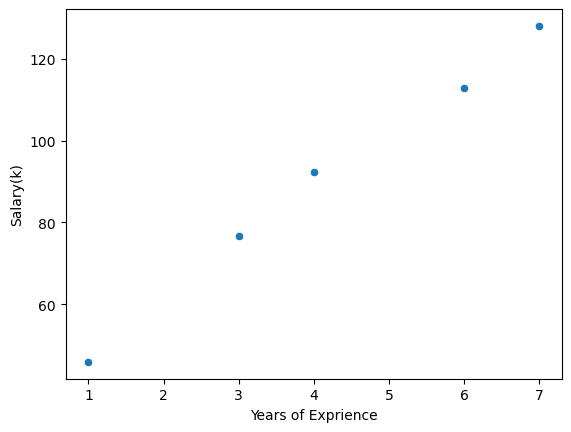

In [9]:
sns.scatterplot(x=X[:, 0:1].ravel(), y=y)
plt.xlabel("Years of Exprience")
plt.ylabel("Salary(k)")
plt.show()

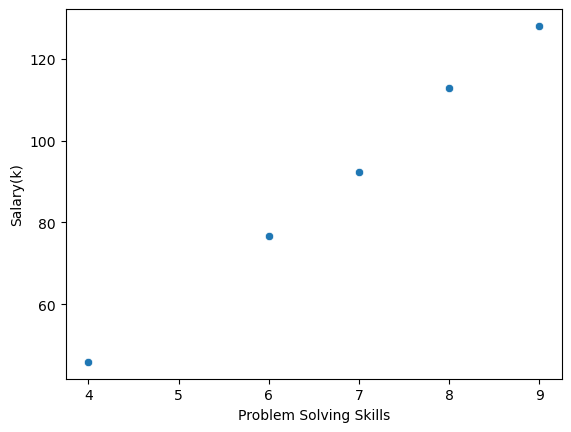

In [10]:
sns.scatterplot(x=X[:, 1:2].ravel(), y=y)
plt.xlabel("Problem Solving Skills")
plt.ylabel("Salary(k)")
plt.show()

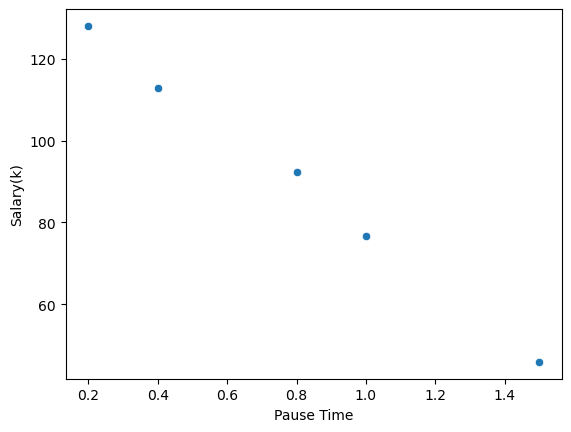

In [11]:
sns.scatterplot(x=X[:, 2:3].ravel(), y=y)
plt.xlabel("Pause Time")
plt.ylabel("Salary(k)")
plt.show()

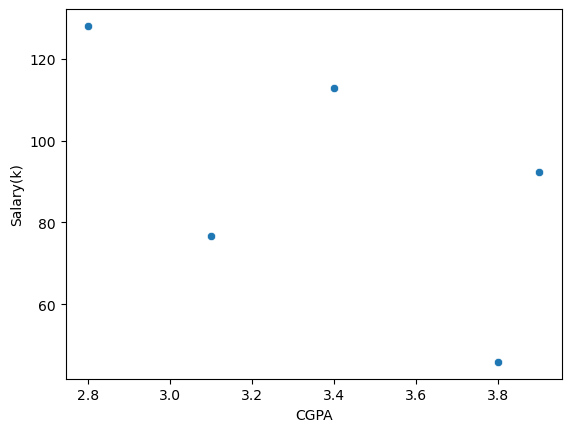

In [12]:
sns.scatterplot(x=X[:, 3:].ravel(), y=y)
plt.xlabel("CGPA")
plt.ylabel("Salary(k)")
plt.show()

In [13]:
def make_prediction(X, y, W, b):
  m = X.shape[0] 
  pred_list = np.zeros((m,))

  for i in range(m):
      pred_list[i] = np.dot(W,X[i]) + b
      
  return pred_list

In [14]:
n = X.shape[1]
w_init = np.ones((n,))
b_init  = 1.0
make_prediction(X, y, w_init, b_init)

array([11.3, 14.1, 16.7, 18.8, 20. ])

In [15]:
def compute_cost(X,y,W,b):
    
    m = X.shape[0] 
    cost = 0.0
    pred_list = make_prediction(X, y, W, b)
    # print(pred_list)
    
    error = pred_list - y
    # print(error)
    
    error_squared = error ** 2
    # print(error_squared)

    cost = np.sum(error_squared)
    
    cost = cost / (2 * m)
    return cost

In [16]:
compute_cost(X, y, w_init, b_init)

np.float64(3133.8895)

In [17]:
def calculate_gradient(X,y,W,b):
    m = X.shape[0] # The number of training example
    n = X.shape[1]
    dj_dw = np.zeros((n,))
    dj_db = 0.0
    for i in  range(m):
        prediction = np.dot(W, X[i]) + b
        error = prediction - y[i] 
        dj_db = dj_db + error
        for j in range(n):
            dj_dw[j] = dj_dw[j] + (error * X[i, j])
        
    return dj_dw / m, dj_db/ m

In [18]:
calculate_gradient(X,y,w_init,b_init)

(array([-369.03 , -553.49 ,  -46.822, -248.49 ]),
 np.float64(-74.96000000000001))

In [19]:
X = np.array([
    [1, 4, 1.5, 3.8],
    [3, 6, 1.0, 3.1],
    [4, 7, 0.8, 3.9],
    [6, 8, 0.4, 3.4],
    [7, 9, 0.2, 2.8]
])
make_prediction(X, y, W =[5, 10, -2, 0.5], b = 2)

array([ 45.9 ,  76.55,  92.35, 112.9 , 128.  ])

In [20]:
def gradient_descent(X, y, w_input, b_input, max_iteration, alpha=0.01):
    w = w_input
    b = b_input

    cost_memo = []
    iteration  = []
    for i in range(max_iteration):
        dj_dw, dj_db = calculate_gradient(X,y,w,b)
        
        # Update
        w = w - (alpha * dj_dw)
        b = b - (alpha * dj_db)

        cost = compute_cost(X,y,w,b)
        cost_memo.append(cost)
        iteration.append(i)

        if i % 100 == 0:
            print(f"iteration:{i}, w:{w}, b:{b:0.4f}, dj_dw:{dj_dw}, dj_db:{dj_db:0.4f}, Cost:{cost:0.4f}")

    return w,b,cost_memo,iteration

In [21]:
W_init = np.zeros((n,))
b_init = 0.0
w_final,b_final,memo,iter = gradient_descent(X, y, w_input= W_init, b_input= b_init, max_iteration=10000, alpha=0.01)

iteration:0, w:[4.4367  6.6891  0.58008 3.0283 ], b:0.9114, dj_dw:[-443.67  -668.91   -58.008 -302.83 ], dj_db:-91.1400, Cost:156.1039
iteration:100, w:[ 6.9123284   8.13950271 -0.26204608  1.85090047], b:0.7323, dj_dw:[-0.22813628 -0.05864     0.1660582   0.40032538], dj_db:0.0633, Cost:0.2098
iteration:200, w:[ 6.94596089  8.20635679 -0.30628534  1.67135256], b:0.7166, dj_dw:[ 0.04414774 -0.0692271  -0.0045622   0.08929593], dj_db:-0.0033, Cost:0.1555
iteration:300, w:[ 6.89119981  8.27458222 -0.29493507  1.59722801], b:0.7225, dj_dw:[ 0.05827911 -0.06692009 -0.01369624  0.06699873], dj_db:-0.0068, Cost:0.1422
iteration:400, w:[ 6.83349662  8.34000876 -0.2814525   1.5327401 ], b:0.7291, dj_dw:[ 0.0567367  -0.06396552 -0.01302088  0.06252647], dj_db:-0.0064, Cost:0.1302
iteration:500, w:[ 6.77796238  8.40251909 -0.26903968  1.47187212], b:0.7352, dj_dw:[ 0.05434933 -0.06110576 -0.01181208  0.05929749], dj_db:-0.0057, Cost:0.1193
iteration:600, w:[ 6.72479865  8.46223713 -0.25782753  1

In [22]:
print(w_final)
print(b_final)

[ 5.37738069  9.87277849 -0.65420072  0.41133992]
0.5344767700708682


## Linear Regression Using Scikit learn

## OlS --> Ordinary Least Square for Small moderate Dataset
## SGD Regressor --> For Large data Set

In [23]:
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import SGDRegressor
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

In [39]:
model1 = LinearRegression()
model1.fit(X, y)
weights = model1.coef_
bias = model1.intercept_

print(weights,bias)

[ 5.  10.  -2.   0.5] 2.000000000000071


In [58]:
model2 = SGDRegressor(penalty=None,max_iter= 1000000000, learning_rate="constant")
model2.fit(X, y)
weights = model2.coef_
bias = model2.intercept_

print(weights, bias)

[6.38765223 8.92783479 0.10877874 0.79353448] [0.90793057]
